# Hadamard Test

量子Hadamard测试是一个用来估计量子态和量子操作的特定属性的量子算法。它可以用来测量一个量子态的相位，或者更一般地，用来测量量子态和量子门操作之间的重叠。

下面将详细解释Hadamard测试的基本步骤。这里我们考虑最简单的形式，即用来测量一个酉操作（量子门）$U$对应于特定量子态$|\psi\rangle$的效果。

### Hadamard Test的设置

我们需要两个寄存器：

1. **控制寄存器**：一个量子比特，初始状态为$|0\rangle$。
2. **目标寄存器**：可以是单个量子比特或者多个量子比特，其初始状态为$|\psi\rangle$。

### Hadamard Test的步骤

1. **初始化**：
   首先，我们将控制寄存器的量子比特准备在$|0\rangle$状态，目标寄存器的量子比特准备在$|\psi\rangle$状态。

2. **应用Hadamard门**：
   然后，我们对控制寄存器的量子比特应用一个Hadamard门$H$。Hadamard门会将$|0\rangle$和$|1\rangle$态变换到叠加态$\frac{|0\rangle + |1\rangle}{\sqrt{2}}$和$\frac{|0\rangle - |1\rangle}{\sqrt{2}}$。

   经过这一步骤后，控制寄存器的状态变为：
   $$\frac{|0\rangle + |1\rangle}{\sqrt{2}}$$

3. **控制操作**：
   接下来，我们执行一个控制$U$操作。这意味着如果控制寄存器在$|1\rangle$状态，那么$U$将会作用在目标寄存器的量子比特上。如果控制寄存器在$|0\rangle$状态，则目标寄存器的状态不变。
   
   操作后的整体状态变为：
   $$\frac{|0\rangle \otimes |\psi\rangle + |1\rangle \otimes U|\psi\rangle}{\sqrt{2}}$$

4. **再次应用Hadamard门**：
   接着，我们在控制寄存器上再次应用Hadamard门。这会将控制寄存器的$|0\rangle$和$|1\rangle$分量与目标寄存器的状态进行进一步的叠加。

   这时候的整体状态将是：
   $$\frac{1}{2} \Big( |0\rangle \otimes (|\psi\rangle + U|\psi\rangle) + |1\rangle \otimes (|\psi\rangle - U|\psi\rangle) \Big)$$

5. **测量控制寄存器**：
   最后，我们测量控制寄存器。测量结果将会是$|0\rangle$或者$|1\rangle$。测量结果的概率分布取决于$|\psi\rangle$和$U|\psi\rangle$的重叠程度。

测量结果和$|\psi\rangle$与$U|\psi\rangle$的关系是：

- 测量控制寄存器得到$|0\rangle$的概率是$P(0) = \frac{1 + \mathrm{Re}\langle\psi|U|\psi\rangle}{2}$。
- 测量控制寄存器得到$|1\rangle$的概率是$P(1) = \frac{1 - \mathrm{Re}\langle\psi|U|\psi\rangle}{2}$。

通过这些概率，我们可以估计量子Hadamard测试是一种量子算法，它可以用来估计和测量量子态的某些特性，比如和一个酉操作（量子门）的相位关系。这种测试的基本思想是利用量子叠加和干涉的性质来提取信息。

### 代码实例

取 $\left|\psi\right\rangle=\frac{\left|0\right\rangle+\left|1\right\rangle}{\sqrt2},U=H$，Hadamard Test的一个DeepQuantum代码实例如下：

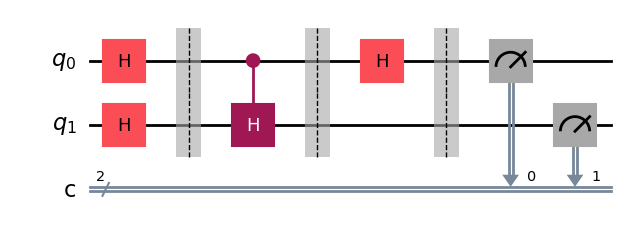

In [1]:
import deepquantum as dq
import numpy as np

def Hadamard_Test():
    cir = dq.QubitCircuit(2)

    # 应用Hadamard门
    cir.h(0)
    cir.h(1)   
    cir.barrier()

    # 控制操作
    cir.h(1,0)
    cir.barrier()

    # 再次应用Hadamard门
    cir.h(0)
    cir.barrier()

    # 测量控制寄存器
    cir.measure(0)

    return cir

# 绘制量子线路图
Hadamard_Test_circuit = Hadamard_Test()
Hadamard_Test_circuit.draw()

输出结果应如下所示，分别以 $\frac{1+\sqrt2/2}{2}$ 和 $1-\frac{1+\sqrt2/2}{2}$ 的概率得到 |0⟩和 |1⟩ ：

In [9]:
Hadamard_Test_circuit()
res = Hadamard_Test_circuit.measure(shots=10000)

p_0=(res['00']+res['01'])/(res['00']+res['01']+res['10']+res['11'])
p_1=(res['10']+res['11'])/(res['00']+res['01']+res['10']+res['11'])

print("p_0:"+str(p_0))
print("p_1:"+str(p_1))

p_0:0.8536
p_1:0.1464
